In [2]:
import pandas as pd



# load data

In [3]:
df = pd.read_csv("../dataset/credit.csv")

# basic understanding of data

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(165)

In [9]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [12]:
"""Total rows: 32,581
Total columns: 12
Missing values are present in 2 columns.
Duplicate records: 165.
Target variable is loan_status.
Dataset contains both numerical and categorical features.
Target classes are slightly imbalanced."""

'Total rows: 32,581\nTotal columns: 12\nMissing values are present in 2 columns.\nDuplicate records: 165.\nTarget variable is loan_status.\nDataset contains both numerical and categorical features.\nTarget classes are slightly imbalanced.'

## EDA (Observe the data)

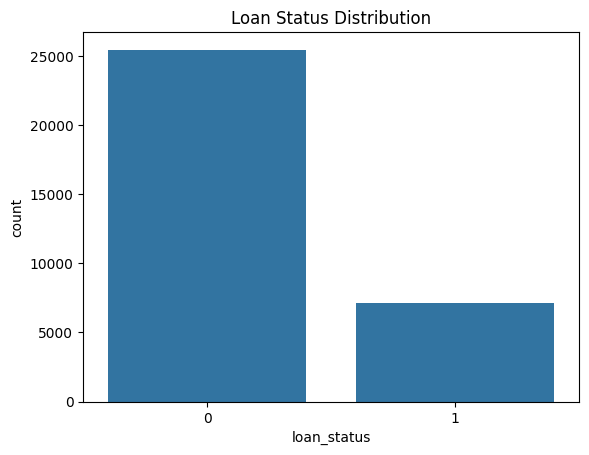

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
# target feature
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

In [14]:
"""Majority customers belong to class 0.
Minority customers belong to class 1.
Dataset is slightly imbalanced."""

'Majority customers belong to class 0.\nMinority customers belong to class 1.\nDataset is slightly imbalanced.'

In [15]:

numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

numerical_columns.remove("loan_status")

In [16]:
numerical_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

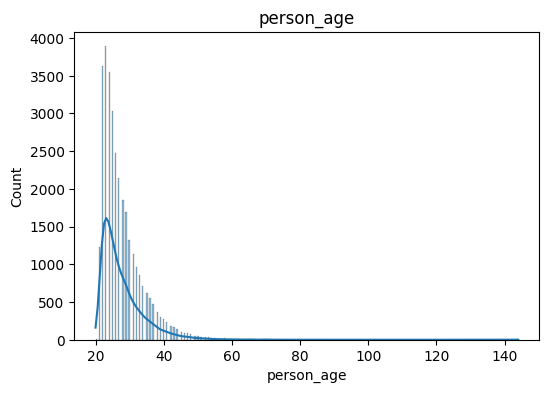

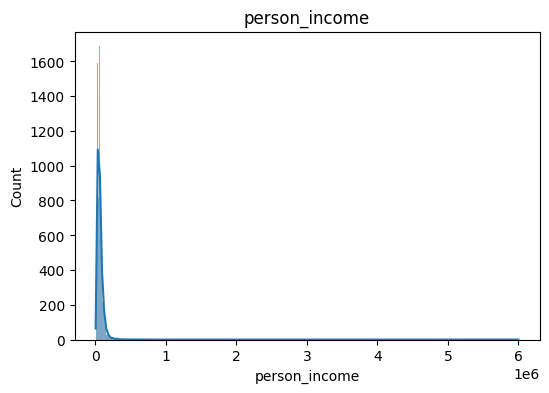

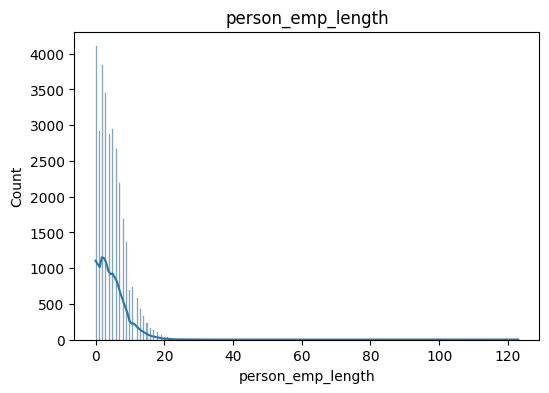

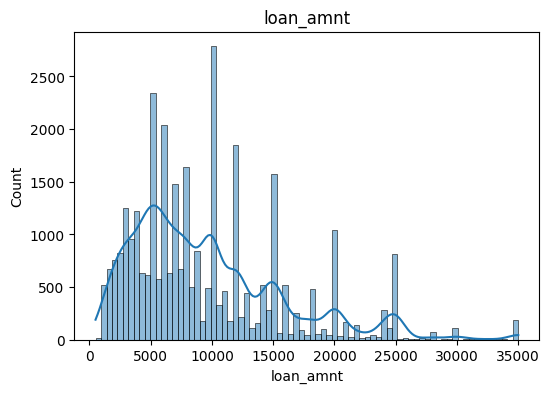

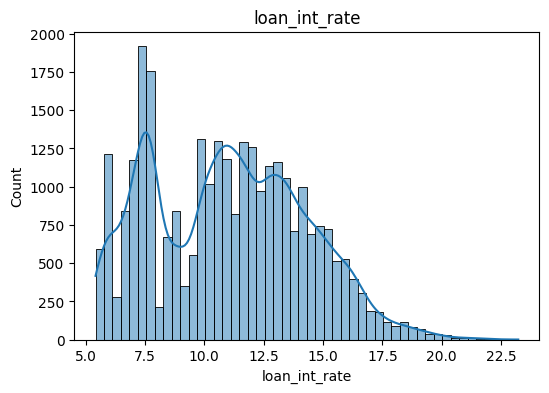

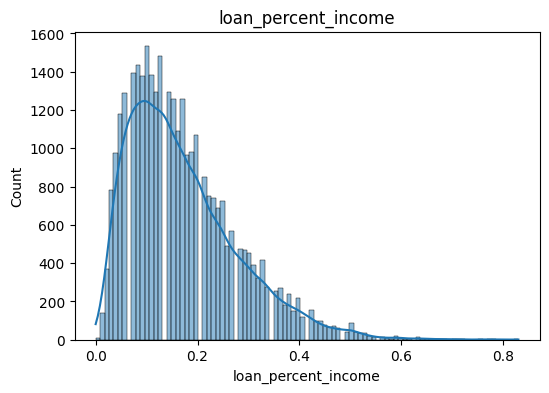

In [17]:
for col in numerical_columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

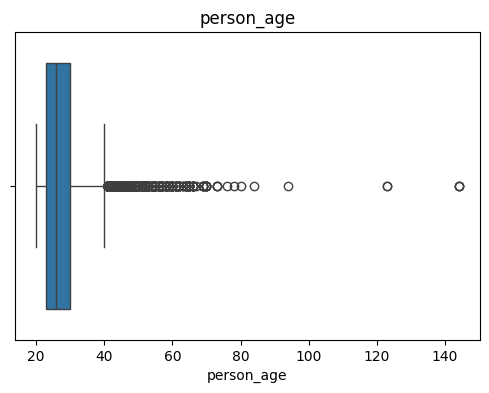

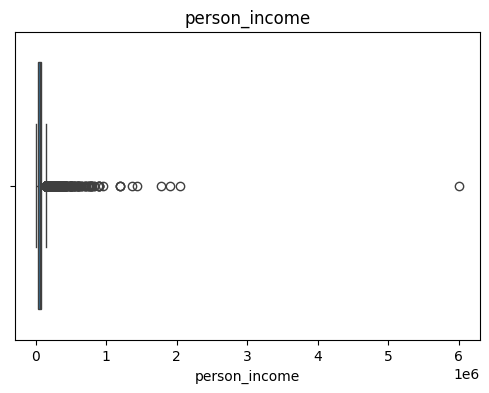

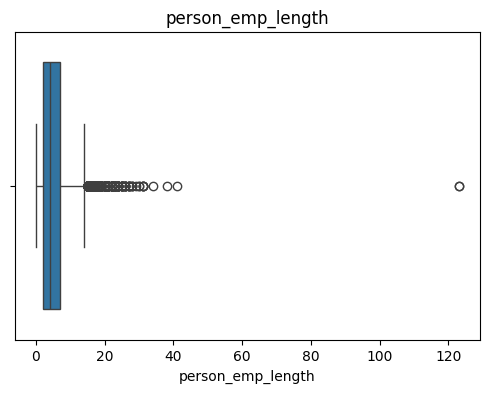

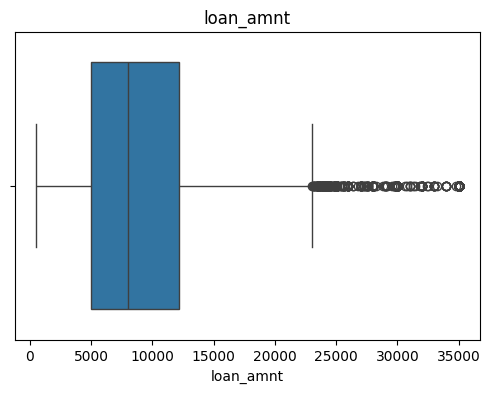

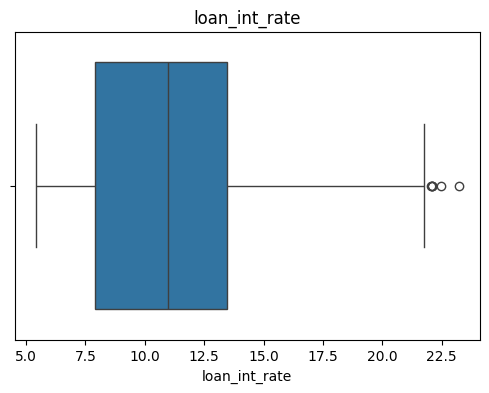

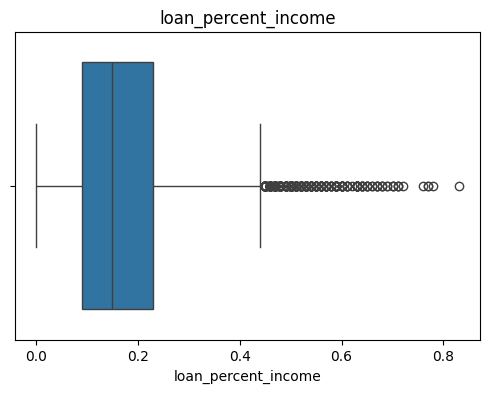

In [18]:
# for the outlier
for col in numerical_columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [19]:
categorical_feature =df.select_dtypes(include ='object').columns

In [20]:
categorical_feature

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

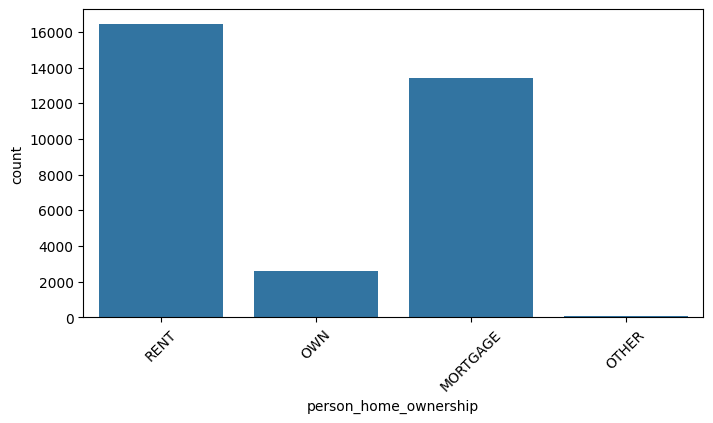

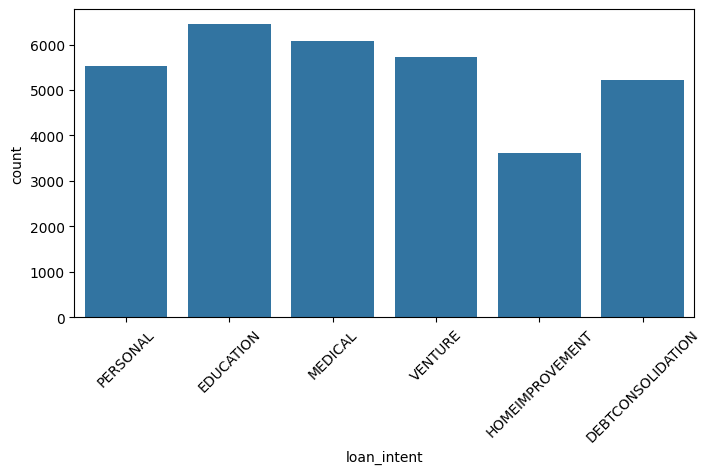

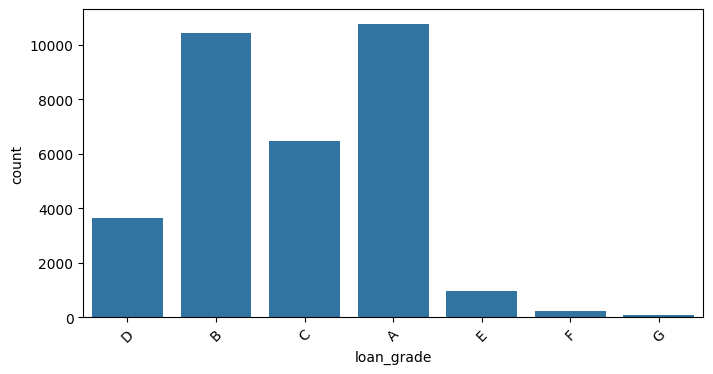

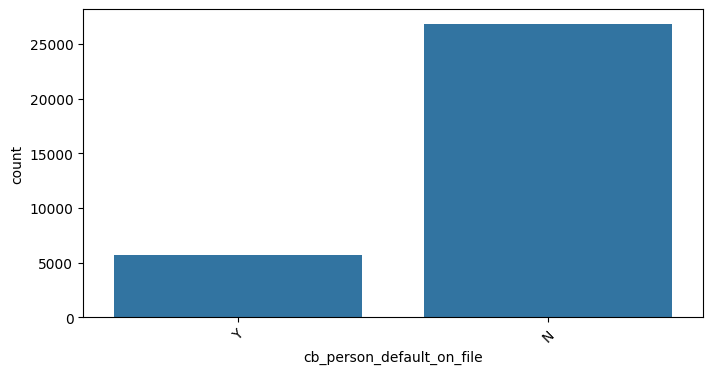

In [21]:
for col in categorical_feature:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

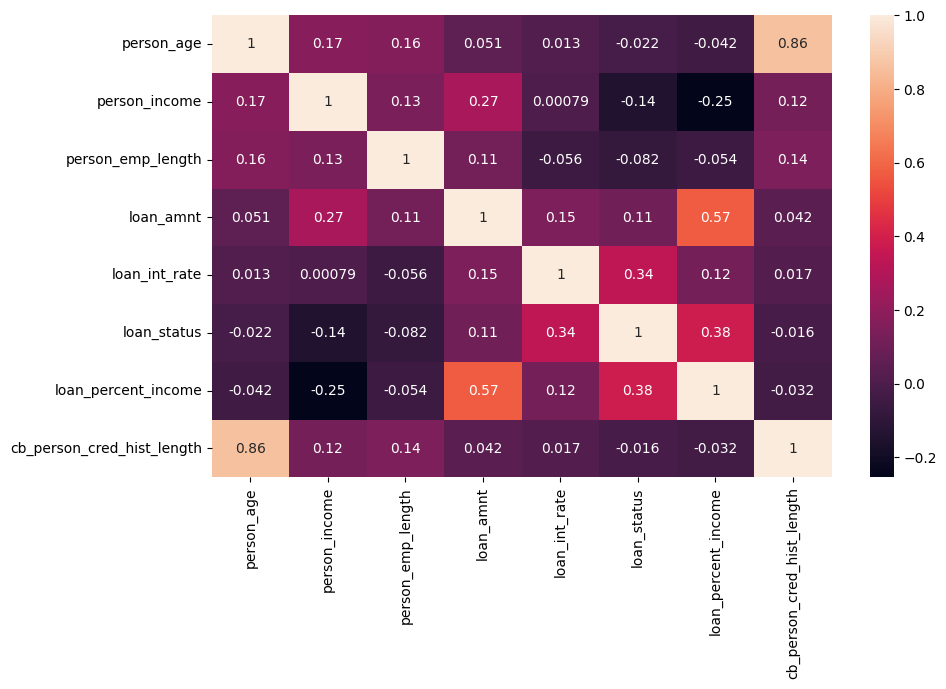

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

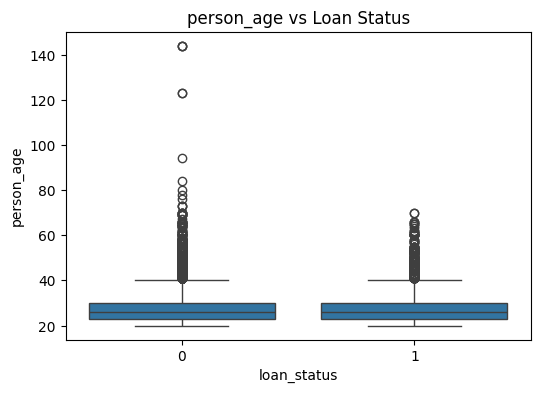

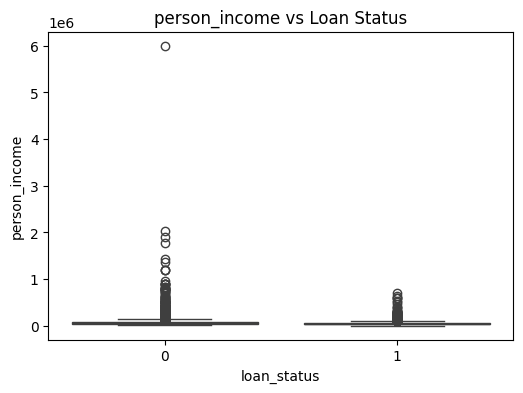

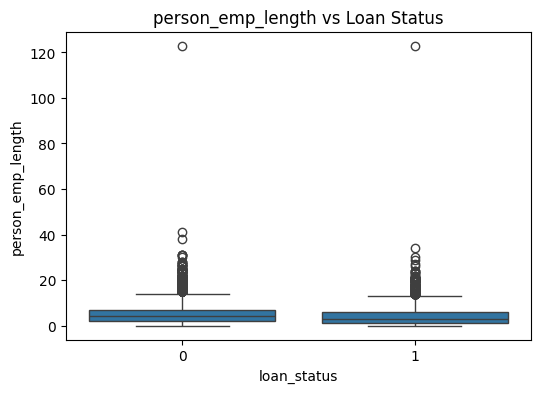

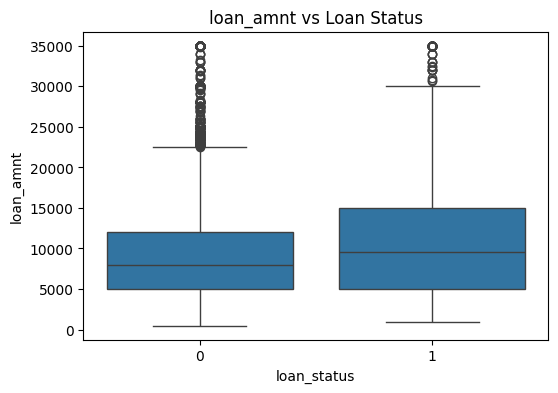

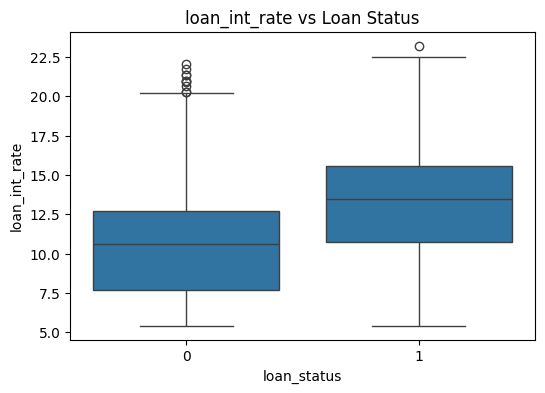

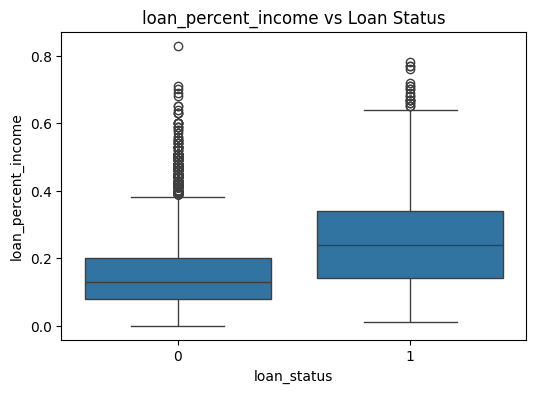

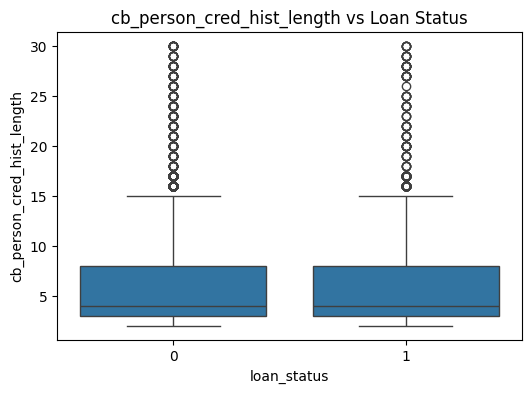

In [23]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="loan_status", y=col, data=df)
    plt.title(f"{col} vs Loan Status")
    plt.show()

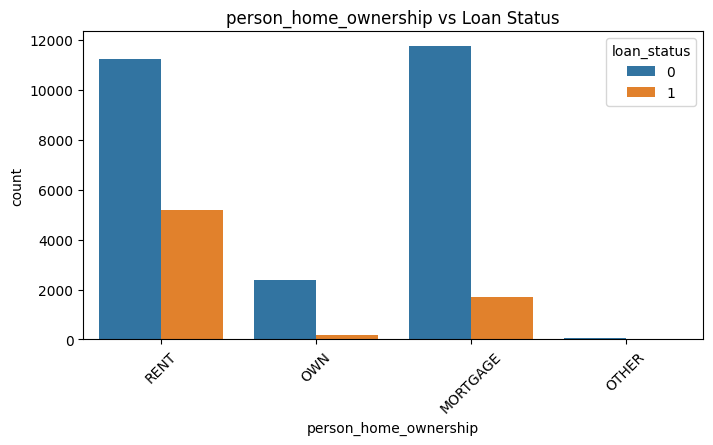

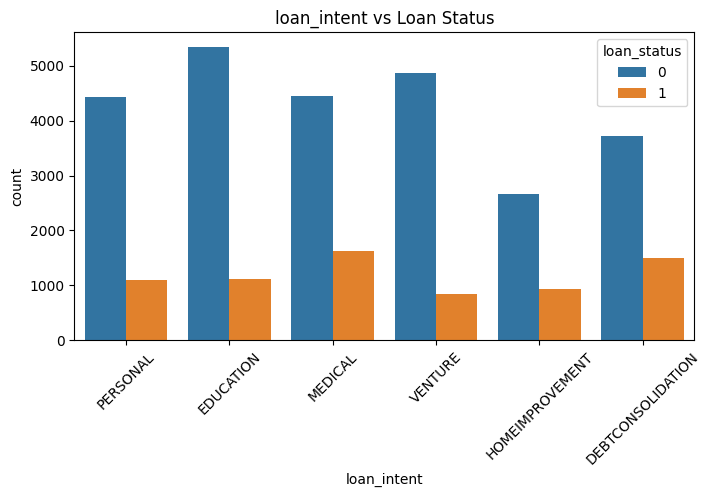

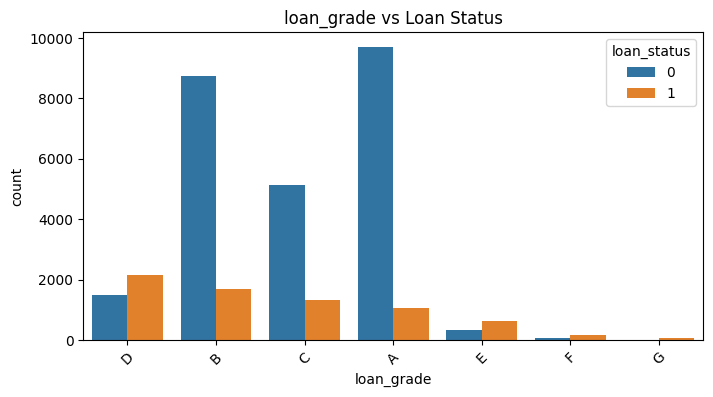

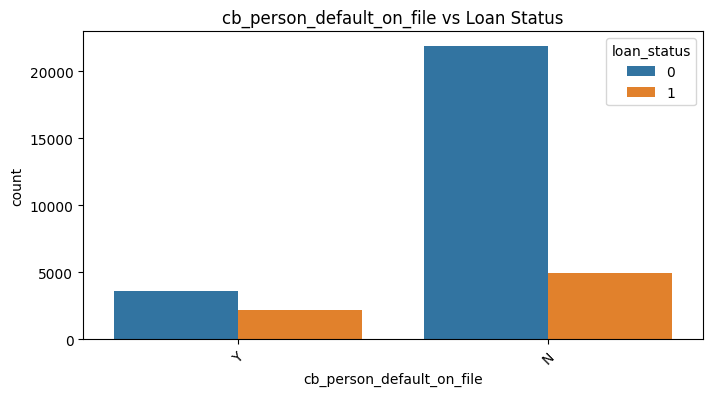

In [24]:
for col in categorical_feature:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue="loan_status", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Loan Status")
    plt.show()

## data cleaning


In [25]:
df.drop_duplicates(inplace=True)

In [27]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

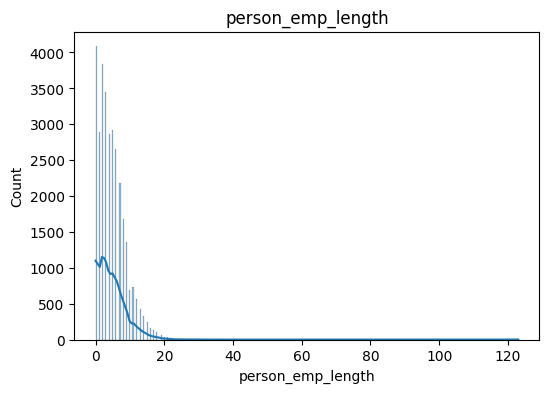

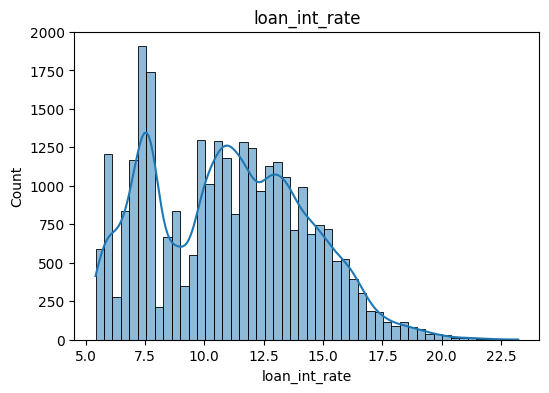

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_cols = ["person_emp_length", "loan_int_rate"]

for col in missing_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [29]:
# Fill missing values using Median

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

In [30]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Encoding

In [31]:
categorical_feature

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [32]:
for col in categorical_feature:
    print(f"\n{col}")
    print(df[col].unique())


person_home_ownership
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

loan_intent
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

loan_grade
['D' 'B' 'C' 'A' 'E' 'F' 'G']

cb_person_default_on_file
['Y' 'N']


In [33]:
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({
    "N": 0,
    "Y": 1
})

In [34]:
grade_mapping = {
    "A":1,
    "B":2,
    "C":3,
    "D":4,
    "E":5,
    "F":6,
    "G":7
}

df["loan_grade"] = df["loan_grade"].map(grade_mapping)

In [35]:
df = pd.get_dummies(
    df,
    columns=[
        "person_home_ownership",
        "loan_intent"
    ],
    drop_first=True
)

In [36]:
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].replace({
    "N": 0,
    "Y": 1
})

In [38]:
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,123.0,4,35000,16.02,1,0.59,1,3,False,False,True,False,False,False,True,False
1,21,9600,5.0,2,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
2,25,9600,1.0,3,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
3,23,65500,4.0,3,35000,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False
4,24,54400,8.0,3,35000,14.27,1,0.55,1,4,False,False,True,False,False,True,False,False


## train test 


In [40]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaling

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# model 


In [54]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=0.5,
    max_iter=1000,
    solver="liblinear",
    random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=42, solver='liblinear')

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision :", precision_score(y_test, y_pred))
    print("Recall :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC :", roc_auc_score(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

In [57]:
print("Logistic Regression")
evaluate_model(lr, X_test_scaled, y_test)


print("\nRandom Forest")
evaluate_model(rf, X_test, y_test)

Logistic Regression
Accuracy : 0.8544108574953733
Precision : 0.7389112903225806
Recall : 0.5169252468265162
F1 Score : 0.6082987551867219
ROC AUC : 0.7329000493903604

Confusion Matrix
[[4807  259]
 [ 685  733]]

Random Forest
Accuracy : 0.933066008636644
Precision : 0.9739884393063584
Recall : 0.7129760225669958
F1 Score : 0.8232899022801303
ROC AUC : 0.8538231869645085

Confusion Matrix
[[5039   27]
 [ 407 1011]]


In [58]:
from sklearn.metrics import accuracy_score

# Train Accuracy
train_pred = rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Test Accuracy
test_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

Train Accuracy : 0.9395
Test Accuracy  : 0.9331


In [61]:
from sklearn.metrics import accuracy_score

# Train Accuracy
train_pred = lr.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

# Test Accuracy
test_pred = lr.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

Train Accuracy : 0.8532
Test Accuracy  : 0.8544


In [60]:
import pickle

with open("credit_scoring_model.pkl", "wb") as file:
    pickle.dump(rf, file)

In [62]:
print(X.columns.tolist())


['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']
